In [125]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [126]:
df = pd.read_excel("./datasets/Specimens-Train.xlsx")
print(f"Data loaded. Total length: {len(df)}")

split_ratio = 0.8
split_idx   = int(split_ratio * len(df))

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

train_A = train_df["TOTAL A"].values
train_S = train_df["TOTAL SPECIMENS"].values
test_A  = test_df["TOTAL A"].values
test_S  = test_df["TOTAL SPECIMENS"].values

print(f"Train : {len(train_df)} samples  ({split_ratio*100:.0f}%)")
print(f"Test  : {len(test_df)} samples   ({(1-split_ratio)*100:.0f}%)")

Data loaded. Total length: 238
Train : 190 samples  (80%)
Test  : 48 samples   (20%)


In [127]:
def universe(series, factor=0.2):
    lo, hi = series.min(), series.max()
    d = factor * (hi - lo)
    return lo - d, hi + d

U_min_A, U_max_A = universe(train_A)
U_min_S, U_max_S = universe(train_S)

print(f"TOTAL A         → U_min={U_min_A:.4f}  U_max={U_max_A:.4f}")
print(f"TOTAL SPECIMENS → U_min={U_min_S:.4f}  U_max={U_max_S:.4f}")

TOTAL A         → U_min=-9763.4000  U_max=58601.4000
TOTAL SPECIMENS → U_min=-11517.8000  U_max=225668.8000


In [ ]:
tau = 17
m   = 3    

n = len(train_A)
N = n - (m - 1) * tau

X_A = np.zeros((N, m))
for i in range(m):
    X_A[:, i] = train_A[i*tau : i*tau + N]

X_S = np.zeros((N, m))
for i in range(m):
    X_S[:, i] = train_S[i*tau : i*tau + N]

print(f"Phase-space TOTAL A         : {X_A.shape}")
print(f"Phase-space TOTAL SPECIMENS : {X_S.shape}")

Phase-space TOTAL A         : (156, 3)
Phase-space TOTAL SPECIMENS : (156, 3)


In [ ]:
c_A = 29  
c_S = 31  

print(f"Clustering TOTAL A         with c={c_A} ...")
cntr_A, u_A, *_ = fuzz.cluster.cmeans(
    X_A.T, c=c_A, m=2.0, error=0.005, maxiter=1000
)
centers_A = np.sort(cntr_A[:, 0]) 

print(f"Clustering TOTAL SPECIMENS with c={c_S} ...")
cntr_S, u_S, *_ = fuzz.cluster.cmeans(
    X_S.T, c=c_S, m=2.0, error=0.005, maxiter=1000
)
centers_S = np.sort(cntr_S[:, 0])   

print(f"\ncenters_A  ({c_A} clusters): {centers_A}")
print(f"\ncenters_S  ({c_S} clusters): {centers_S}")

Clustering TOTAL A         with c=29 ...
Clustering TOTAL SPECIMENS with c=31 ...

centers_A  (29 clusters): [  105.87701458   119.6715518    122.48477191   138.48050337
   234.07814792   244.66915102   288.79810968   298.27645365
   321.1089066    322.24575965   348.34093563   358.72228941
   628.95118213   739.73806629  1170.07116359  2512.3888094
  3394.10843153  4375.21612136  5795.93581231  5907.59869321
  6560.426147    6609.64766376  9742.96144554 16098.26914456
 21827.32633785 30030.91621265 40584.95501797 42064.35359695
 48280.55610138]

centers_S  (31 clusters): [ 24118.76247066  30566.46845299  33651.18060059  36069.12413567
  38069.52165215  38613.49725155  40148.98258228  42615.50075101
  47022.55097427  49118.36450859  52185.6610133   53434.12715099
  57464.6287684   59127.16402058  61719.18356826  64675.17432206
  64692.77427783  67686.15401593  68083.57481799  70129.8517396
  72174.89907382  80452.45668009  82512.280435    87298.21923809
  95177.4454131   95726.15312723

In [150]:
def build_fuzzy_sets(centers, u_min, u_max):
    """Build triangular fuzzy sets from sorted cluster centres."""
    boundaries = [(centers[i] + centers[i+1]) / 2 for i in range(len(centers) - 1)]
    intervals  = [(u_min, boundaries[0])]
    for i in range(len(boundaries) - 1):
        intervals.append((boundaries[i], boundaries[i+1]))
    intervals.append((boundaries[-1], u_max))

    fs = []
    for i, b in enumerate(centers):
        if i == 0:
            a, c = intervals[0][0], centers[1]
        elif i == len(centers) - 1:
            a, c = centers[-2], intervals[-1][1]
        else:
            a, c = centers[i-1], centers[i+1]
        fs.append((a, b, c))
    return fs

fuzzy_sets_A = build_fuzzy_sets(centers_A, U_min_A, U_max_A)
fuzzy_sets_S = build_fuzzy_sets(centers_S, U_min_S, U_max_S)

print(f"Fuzzy sets for TOTAL A         : {len(fuzzy_sets_A)}")
print(f"Fuzzy sets for TOTAL SPECIMENS : {len(fuzzy_sets_S)}")

Fuzzy sets for TOTAL A         : 29
Fuzzy sets for TOTAL SPECIMENS : 31


In [151]:
def triangular_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    return (x - a) / (b - a) if x <= b else (c - x) / (c - b)

def which_partition(value, fuzzy_sets):
    mfs  = [triangular_mf(value, *fs) for fs in fuzzy_sets]
    best = int(np.argmax(mfs))
    return None if mfs[best] == 0 else best

def fuzzify_series(values, fuzzy_sets):
    return np.array([
        (which_partition(v, fuzzy_sets) if which_partition(v, fuzzy_sets) is not None else -1)
        for v in values
    ])

print("Helper functions defined.")

Helper functions defined.


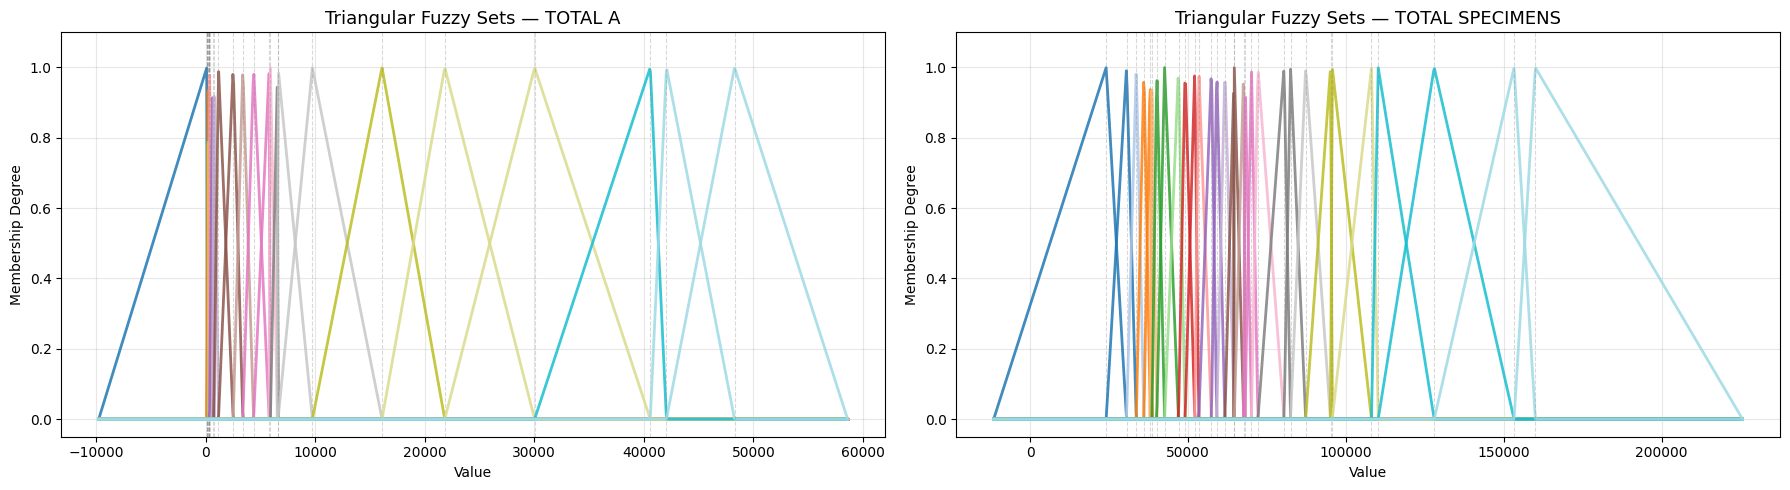

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (fsets, u_lo, u_hi, title) in zip(
    axes,
    [
        (fuzzy_sets_A, U_min_A, U_max_A, "TOTAL A"),
        (fuzzy_sets_S, U_min_S, U_max_S, "TOTAL SPECIMENS"),
    ]
):
    x_plot = np.linspace(u_lo, u_hi, 1000)
    colors  = plt.cm.tab20(np.linspace(0, 1, len(fsets)))
    for i, (a, b, c) in enumerate(fsets):
        y = [triangular_mf(v, a, b, c) for v in x_plot]
        ax.plot(x_plot, y, color=colors[i], linewidth=2, alpha=0.85)
        ax.axvline(b, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.set_title(f"Triangular Fuzzy Sets — {title}", fontsize=13)
    ax.set_xlabel("Value")
    ax.set_ylabel("Membership Degree")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

In [153]:
all_A = df["TOTAL A"].values
all_S = df["TOTAL SPECIMENS"].values

labels_A = fuzzify_series(all_A, fuzzy_sets_A)
labels_S = fuzzify_series(all_S, fuzzy_sets_S)

labels_train_A = labels_A[:len(train_df)]
labels_train_S = labels_S[:len(train_df)]
labels_test_A  = labels_A[len(train_df):]
labels_test_S  = labels_S[len(train_df):]

print("Labels TOTAL A (first 10):", labels_train_A[:10])
print("Labels TOTAL S (first 10):", labels_train_S[:10])

Labels TOTAL A (first 10): [0 0 0 0 0 0 0 0 0 0]
Labels TOTAL S (first 10): [8 7 5 3 3 2 2 2 2 2]


In [154]:
flrg = defaultdict(lambda: defaultdict(int))

for t in range(len(labels_train_A) - 1):
    key = (labels_train_A[t], labels_train_S[t])
    rhs = labels_train_A[t + 1]
    flrg[key][rhs] += 1

print(f"FLRG entries (First-Order, multivariate): {len(flrg)}")
print()
for i, (lhs, rhs_dict) in enumerate(sorted(flrg.items())):
    rhs_str = ", ".join(f"A{r+1}({w})" for r, w in rhs_dict.items())
    print(f"  (A{lhs[0]+1}, S{lhs[1]+1})  →  {rhs_str}")


FLRG entries (First-Order, multivariate): 111

  (A1, S1)  →  A1(8)
  (A1, S2)  →  A1(11)
  (A1, S3)  →  A1(7)
  (A1, S4)  →  A1(5)
  (A1, S6)  →  A1(1)
  (A1, S7)  →  A1(3)
  (A1, S8)  →  A1(3)
  (A1, S9)  →  A1(2)
  (A1, S10)  →  A1(2)
  (A1, S11)  →  A3(1)
  (A3, S13)  →  A8(1)
  (A4, S2)  →  A5(1)
  (A4, S4)  →  A5(1)
  (A5, S2)  →  A7(1), A5(1), A4(1)
  (A5, S3)  →  A5(1), A4(1)
  (A5, S4)  →  A5(1)
  (A5, S7)  →  A5(2)
  (A5, S8)  →  A6(1), A5(1)
  (A5, S9)  →  A5(3), A6(1)
  (A5, S10)  →  A5(1)
  (A5, S11)  →  A5(1)
  (A5, S12)  →  A8(1), A5(3)
  (A5, S13)  →  A5(1)
  (A6, S8)  →  A5(2)
  (A6, S12)  →  A5(1), A6(1), A9(1)
  (A7, S2)  →  A5(1)
  (A7, S13)  →  A6(1)
  (A7, S15)  →  A5(1)
  (A8, S5)  →  A11(1)
  (A8, S7)  →  A6(1)
  (A8, S13)  →  A10(1)
  (A8, S16)  →  A14(1)
  (A9, S13)  →  A11(1)
  (A10, S14)  →  A12(1)
  (A11, S5)  →  A8(1)
  (A11, S7)  →  A8(1)
  (A11, S15)  →  A7(1), A12(1)
  (A12, S8)  →  A11(1)
  (A12, S14)  →  A13(1)
  (A12, S15)  →  A11(1), A12(1)
  (A12, 

In [155]:
order = 2

flrg_ho = defaultdict(lambda: defaultdict(int))

for t in range(order, len(labels_train_A)):
    lhs = tuple(
        labels_train_A[t - order + i] if j == 0 else labels_train_S[t - order + i]
        for i in range(order)
        for j in range(2)
    )
    rhs = labels_train_A[t]
    flrg_ho[lhs][rhs] += 1

print(f"High-order FLRG entries (order={order}, multivariate): {len(flrg_ho)}")
print()
for i, (lhs, rhs_dict) in enumerate(sorted(flrg_ho.items())[:5]):
    pair_str = ", ".join(
        f"(A{lhs[2*k]+1},S{lhs[2*k+1]+1})" for k in range(order)
    )
    rhs_str = ", ".join(f"A{r+1}({w})" for r, w in rhs_dict.items())
    print(f"  [{pair_str}]  →  {rhs_str}")

High-order FLRG entries (order=2, multivariate): 165

  [(A1,S1), (A1,S1)]  →  A1(7)
  [(A1,S1), (A1,S2)]  →  A1(1)
  [(A1,S2), (A1,S1)]  →  A1(1)
  [(A1,S2), (A1,S2)]  →  A1(9)
  [(A1,S2), (A1,S4)]  →  A1(1)


In [ ]:
def centroid_defuzz(rhs_dict, centers):
    if not rhs_dict:
        return np.nan
    num = sum(centers[idx] * w for idx, w in rhs_dict.items())
    den = sum(rhs_dict.values())
    return num / den


def predict_fofts_mv(t, labels_A, labels_S, flrg, centers_A, fuzzy_sets_A):
    key = (labels_A[t], labels_S[t])
    if key in flrg and flrg[key]:
        return centroid_defuzz(flrg[key], centers_A)
    merged = defaultdict(int)
    for k, rhs_dict in flrg.items():
        if k[0] == labels_A[t]:
            for r, w in rhs_dict.items():
                merged[r] += w
    return centroid_defuzz(merged, centers_A) if merged else centers_A[labels_A[t]]


def predict_hofts_mv(t, labels_A, labels_S, flrg_ho, centers_A, order):
    lhs = tuple(
        labels_A[t - order + i] if j == 0 else labels_S[t - order + i]
        for i in range(order)
        for j in range(2)
    )
    if lhs in flrg_ho and flrg_ho[lhs]:
        return centroid_defuzz(flrg_ho[lhs], centers_A)
    fallback_key = tuple(labels_A[t - order + i] for i in range(order))
    merged = defaultdict(int)
    for k, rhs_dict in flrg_ho.items():
        if tuple(k[2*i] for i in range(order)) == fallback_key:
            for r, w in rhs_dict.items():
                merged[r] += w
    return centroid_defuzz(merged, centers_A) if merged else centers_A[labels_A[t]]


print("Prediction functions defined.")

Prediction functions defined.


In [ ]:
pred_fofts = np.array([
    predict_fofts_mv(t, labels_test_A, labels_test_S,
                     flrg, centers_A, fuzzy_sets_A)
    for t in range(len(test_A) - 1)
])
actual_fofts = test_A[1:]

pred_hofts = np.array([
    predict_hofts_mv(t, labels_test_A, labels_test_S,
                     flrg_ho, centers_A, order)
    for t in range(order, len(test_A))
])
actual_hofts = test_A[order:]

print(f"FOFTS predictions : {len(pred_fofts)}  samples")
print(f"HOFTS predictions : {len(pred_hofts)}  samples")

FOFTS predictions : 47  samples
HOFTS predictions : 46  samples


In [158]:
def compute_metrics(y_true, y_pred, name="Model"):
    mse  = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    acc  = 100 - mape

    print(f"\n{name}")
    print(f"   MSE      = {mse:10.6f}")
    print(f"   RMSE     = {rmse:10.4f}")
    print(f"   MAE      = {mae:10.4f}")
    print(f"   MAPE     = {mape:10.3f} %")
    print(f"   R²       = {r2:10.4f}")
    print(f"   Accuracy = {acc:10.3f} %")
    return mse, rmse, mae, mape, r2, acc

print("=" * 60)
print("   TEST SET — MULTIVARIATE FTS  (TOTAL A + TOTAL SPECIMENS)")
print("=" * 60)

m_fofts = compute_metrics(actual_fofts, pred_fofts,
                           "FOFTS (multivariate, one-step)")
m_hofts = compute_metrics(actual_hofts, pred_hofts,
                           f"HOFTS (multivariate, order={order}, one-step)")

best = "HOFTS" if m_hofts[0] < m_fofts[0] else "FOFTS"
print("\n" + "-" * 60)
print(f"Best model → {best}")
print("-" * 60)

   TEST SET — MULTIVARIATE FTS  (TOTAL A + TOTAL SPECIMENS)

FOFTS (multivariate, one-step)
   MSE      = 34496381.420176
   RMSE     =  5873.3620
   MAE      =  2887.1783
   MAPE     =     47.583 %
   R²       =     0.8388
   Accuracy =     52.417 %

HOFTS (multivariate, order=2, one-step)
   MSE      = 10126948.564821
   RMSE     =  3182.2867
   MAE      =  1349.9388
   MAPE     =     21.636 %
   R²       =     0.9533
   Accuracy =     78.364 %

------------------------------------------------------------
Best model → HOFTS
------------------------------------------------------------


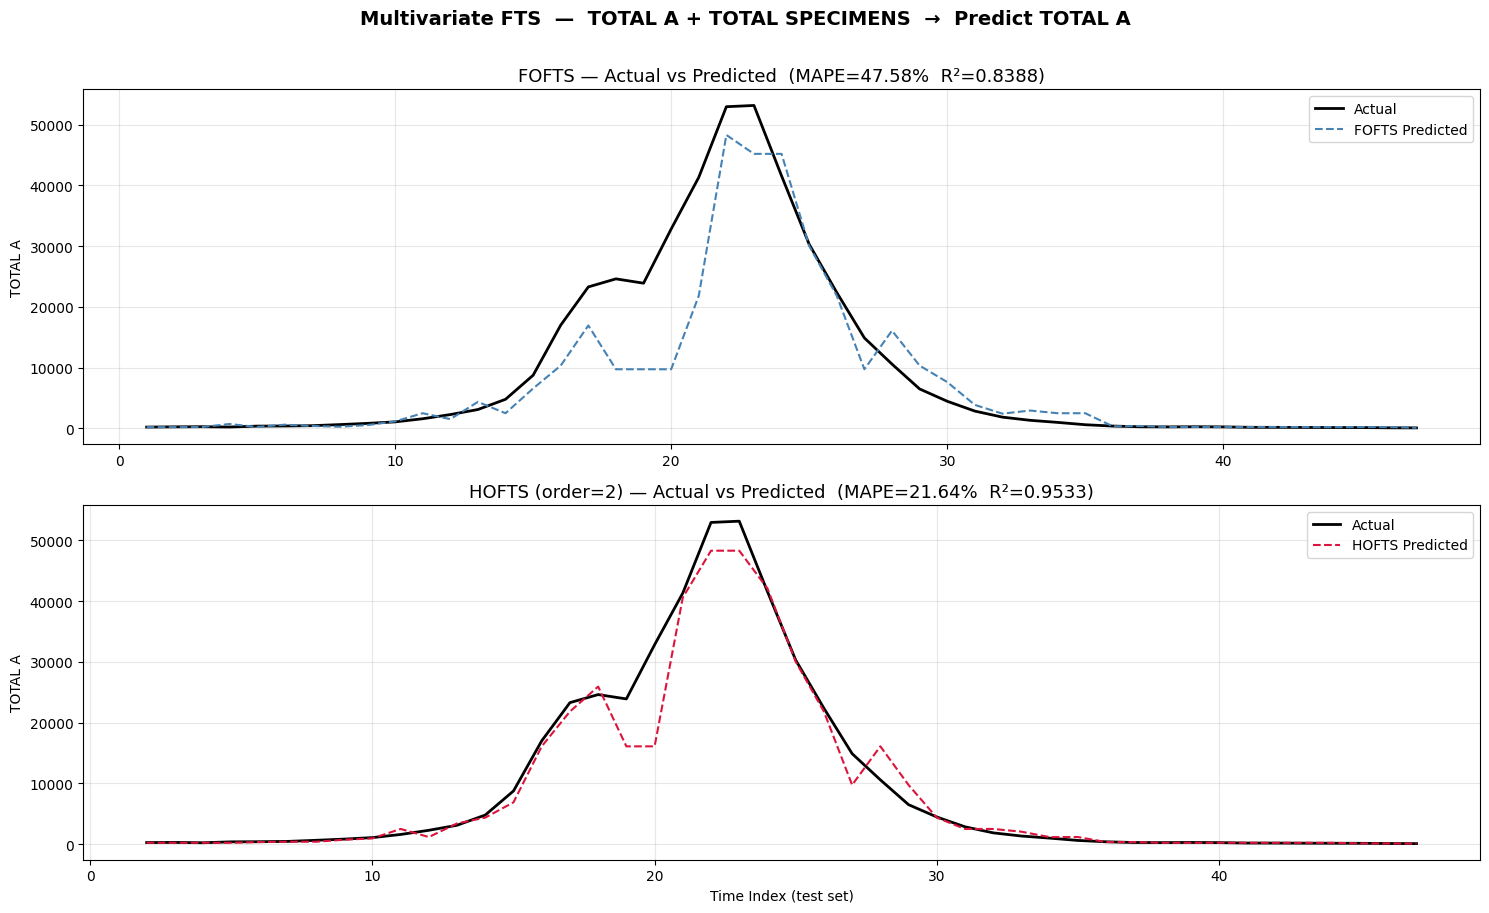

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

ax = axes[0]
t_fo = np.arange(1, len(test_A))
ax.plot(t_fo, actual_fofts, label="Actual",          color="black",    linewidth=2)
ax.plot(t_fo, pred_fofts,   label="FOFTS Predicted", color="steelblue", linestyle="--", linewidth=1.5)
ax.set_title(f"FOFTS — Actual vs Predicted  (MAPE={m_fofts[3]:.2f}%  R²={m_fofts[4]:.4f})",
             fontsize=13)
ax.set_ylabel("TOTAL A")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
t_ho = np.arange(order, len(test_A))
ax.plot(t_ho, actual_hofts, label="Actual",          color="black",  linewidth=2)
ax.plot(t_ho, pred_hofts,   label="HOFTS Predicted", color="crimson", linestyle="--", linewidth=1.5)
ax.set_title(f"HOFTS (order={order}) — Actual vs Predicted  "
             f"(MAPE={m_hofts[3]:.2f}%  R²={m_hofts[4]:.4f})", fontsize=13)
ax.set_xlabel("Time Index (test set)")
ax.set_ylabel("TOTAL A")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Multivariate FTS  —  TOTAL A + TOTAL SPECIMENS  →  Predict TOTAL A",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()